In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

cuda:0


In [2]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import numpy as np  # 确保导入 numpy，否则后续使用 np 会报错



class LangPairDataset(Dataset):
    """
    德英平行语料数据集，支持缓存机制，自动过滤超长句子。
    """

    def __init__(
        self, mode="train", max_length=512, overwrite_cache=False, data_dir="wmt16",
    ):
        # 将数据目录转换为 Path 对象，方便路径拼接
        self.data_dir = Path(data_dir)
        # 构造缓存文件路径：.cache/de2en_{mode}_{max_length}.npy
        cache_path = self.data_dir / ".cache" / f"de2en_{mode}_{max_length}.npy"

        # 若强制重写缓存或缓存不存在，则重新处理并保存
        if overwrite_cache or not cache_path.exists():
            # 确保缓存目录存在
            cache_path.parent.mkdir(parents=True, exist_ok=True)

            # 读取源语言（德语）BPE 文件
            with open(self.data_dir / f"{mode}_src.bpe", "r", encoding="utf8") as file:
                self.src = file.readlines()

            # 读取目标语言（英语）BPE 文件
            with open(self.data_dir / f"{mode}_trg.bpe", "r", encoding="utf8") as file:
                self.trg = file.readlines()

            # 过滤掉长度超过 max_length 的句子对
            filtered_src = []
            filtered_trg = []
            for src, trg in zip(self.src, self.trg):
                if len(src) <= max_length and len(trg) <= max_length:
                    filtered_src.append(src.strip())  # 去除首尾空白
                    filtered_trg.append(trg.strip())

            # 转换为 NumPy 数组，便于后续保存
            filtered_src = np.array(filtered_src)
            filtered_trg = np.array(filtered_trg)

            # 将过滤后的数据以字典形式保存为缓存文件
            np.save(
                cache_path,
                {"src": filtered_src, "trg": filtered_trg},
                allow_pickle=True,  # 允许保存对象类型
            )
            print(f"缓存已保存至 {cache_path}")

        else:
            # 直接加载缓存
            cache_dict = np.load(cache_path, allow_pickle=True).item()
            print(f"已从缓存加载 {mode} 数据集：{cache_path}")
            filtered_src = cache_dict["src"]
            filtered_trg = cache_dict["trg"]

        # 将过滤后的数据赋值给实例属性
        self.src = filtered_src
        self.trg = filtered_trg

    def __getitem__(self, index):
        # 返回指定索引的源句和目标句
        return self.src[index], self.trg[index]

    def __len__(self):
        # 返回数据集大小
        return len(self.src)


# 构造训练集与验证集实例
train_ds = LangPairDataset("train")
val_ds = LangPairDataset("val")

已从缓存加载 train 数据集：wmt16\.cache\de2en_train_512.npy
已从缓存加载 val 数据集：wmt16\.cache\de2en_val_512.npy


In [3]:
word2index = {
    "[PAD]": 0,
    "[BOS]": 1,
    "[UNK]": 2,
    "[EOS]": 3,
}
index2word = {v: k for k, v in word2index.items()}
index = len(index2word)
threshold = 1

with open("wmt16/vocab", "r", encoding="utf8") as f:
    for line in tqdm(f.readlines()):
        token, counts = line.strip().split()
        if int(counts) >= threshold:
            word2index[token] = index
            index2word[index] = token
            index += 1

vocab_size = len(word2index)
print(vocab_size)

  0%|          | 0/18107 [00:00<?, ?it/s]

18111


In [6]:
class Tokenizer:
    def __init__(self, word2index, index2word, max_length=512, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        #
        self.index2word = index2word      # 索引到单词的映射
        self.word2index = word2index
        self.max_length = max_length  # 最长序列长度，一个样本的id数目，不能超过这个
        self.pad_idx = pad_idx        # 填充token的索引
        self.bos_idx = bos_idx        # 句子开头token的索引
        self.eos_idx = eos_idx        # 句子结尾token的索引
        self.unk_idx = unk_idx        # 未知token的索引

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """如果padding_first == True，则padding加载前面，否则加载后面"""
        # 计算当前批次的最大序列长度（加上bos/eos后不要超过设定max_length）
        max_length = min(self.max_length, add_eos + add_bos + max([len(text) for text in text_list]))
        indices_list = []  # 保存编码后的索引序列
        for text in text_list:
            # 对单词编码，超长则截断，每个单词查表得到索引，否则为unk
            indices = [self.word2index.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]
            if add_bos:
                indices = [self.bos_idx] + indices   # 是否在前面加bos
            if add_eos:
                indices = indices + [self.eos_idx]   # 是否在末尾加eos
            if padding_first:
                # 若padding打头，前面补pad
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # 否则结尾补pad
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)  # 添加到结果列表
        input_ids = torch.tensor(indices_list)   # 转为张量
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64) # 1表示pad的位置，用于损失函数忽略pad
        return input_ids if not return_mask else (input_ids, masks)  # 返回索引或(索引, mask)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        text_list = []  # 保存解码后的结果
        for indices in indices_list:
            text = []   # 单句
            for index in indices:
                word = self.index2word.get(index, "[UNK]")  # 索引转单词
                if remove_bos and word == "[BOS]":  # 忽略bos
                    continue
                if remove_eos and word == "[EOS]":  # 遇到eos就停止
                    break
                if remove_pad and word == "[PAD]":  # 遇到pad就停止
                    break
                text.append(word)     # 添加单词
            text_list.append(" ".join(text) if not split else text)  # join成句子或直接返回词list
        return text_list

# 实例化分词器
tokenizer = Tokenizer(word2index=word2index, index2word=index2word)

# 测试输入
raw_text = [
    "two young , white males are outside near many bushes .".split(), 
    "several men in hard hats are operating a giant pulley system .".split(), 
    "a bunch of elderly women play their clarin@@ ets together as they read off sheet music .".split()
]
indices = tokenizer.encode(raw_text, padding_first=False, add_bos=True, add_eos=True)  # 编码
decode_text = tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)  # 解码
print("raw text")     # 原始输入
for raw in raw_text:
    print(raw)
print("indices")      # 索引表示
for index in indices:
    print(index)
print("decode text")  # 还原输出
for decode in decode_text:
    print(decode)

raw text
['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
['several', 'men', 'in', 'hard', 'hats', 'are', 'operating', 'a', 'giant', 'pulley', 'system', '.']
['a', 'bunch', 'of', 'elderly', 'women', 'play', 'their', 'clarin@@', 'ets', 'together', 'as', 'they', 'read', 'off', 'sheet', 'music', '.']
indices
tensor([   1,   28,   38,    9,   40, 1580,   30,  111,  151,  372, 2931,    4,
           3,    0,    0,    0,    0,    0,    0])
tensor([    1,   209,    51,     6,   628,   530,    30,  2578,     5,  1459,
        12584,  4930,     4,     3,     0,     0,     0,     0,     0])
tensor([    1,     5,  1140,    20,   426,    91,   239,   129, 17602,  9951,
          242,   113,   447,  2932,   216,  2112,   623,     4,     3])
decode text
[BOS] two young , white males are outside near many bushes . [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
[BOS] several men in hard hats are operating a giant pulley system . [EOS] [PAD] [PAD] [PAD] [PAD] [PAD]
[B

In [7]:
class SampleInfo: #下面的info对象
    def __init__(self, i, lens):
        """
        记录文本对的序号和长度信息。
        输入：
            - i (int): 文本对的序号。
            - lens (list): 文本对源语言和目标语言的长度
        """
        self.i = i
        # 加一是考虑填补在文本前后的特殊词元，lens[0]和lens[1]分别表示源语言和目标语言的长度
        self.max_len = max(lens[0], lens[1]) + 1
        self.src_len = lens[0] + 1
        self.trg_len = lens[1] + 1

# 一个批量生成器，根据词元数目的限制来控制批量的大小。它会根据传入的样本信息，在不超过设定大小的情况下，逐步构建批量。
class TokenBatchCreator:
    def __init__(self, batch_size):
        """
        参数:
        batch_size (int): 用于限制批量的大小。
        功能:
        初始化了一个空的批量列表 _batch。
        设定了初始的最大长度为 -1。
        存储了传入的 batch_size。
        """

        self._batch = []  #这个就是之前的batch_size，就是第一个batch内有多少个样本
        self.max_len = -1  #始终记录当前箱子内的最长样本的长度
        self._batch_size = batch_size # 限制批量的大小,假设是4096,宽*长

    def append(self, info: SampleInfo):
        """
        参数:
        info (SampleInfo): 文本对的信息。
        功能:
        接收一个 SampleInfo 对象，并根据其最大长度信息更新当前批量的最大长度。
        如果将新的样本加入批量后超过了批量大小限制，它会返回已有的批量并将新的样本加入新的批量。
        否则，它会更新最大长度并将样本添加到当前批量中。
        """
        # 更新当前批量的最大长度
        cur_len = info.max_len # 当前样本的长度
        max_len = max(self.max_len, cur_len) # 每来一个样本，更新当前批次的最大长度
        # 如果新的样本加入批量后超过大小限制，则将已有的批量返回，新的样本加入新的批量
        if max_len * (len(self._batch) + 1) > self._batch_size:
            self._batch, result = [], self._batch # 保存当前的batch，并返回,这里的result是之前的batch,_batch清空
            self._batch.append(info) #箱子里的第一条样本，放入
            self.max_len = cur_len #因为是当前batch的第一个样本，所以它的长度就是当前长度
            return result
        else:
            self.max_len = max_len
            self._batch.append(info) # 将样本添加到当前批量中
            return None

    @property
    def batch(self):
        return self._batch

In [8]:
from torch.utils.data import BatchSampler
import numpy as np


class TransformerBatchSampler(BatchSampler):
    def __init__(self,
                 dataset,
                 batch_size,
                 shuffle_batch=False,
                 clip_last_batch=False,
                 seed=0):
        """
        批量采样器
        输入:
            - dataset: 数据集
            - batch_size: 批量大小，箱子的 宽*长
            - shuffle_batch: 是否对生成的批量进行洗牌，打乱的是箱子
            - clip_last_batch: 是否裁剪最后剩下的数据
            - seed: 随机数种子
        """
        self._dataset = dataset 
        self._batch_size = batch_size
        self._shuffle_batch = shuffle_batch
        self._clip_last_batch = clip_last_batch
        self._seed = seed #下面3个是为了随机
        self._random = np.random
        self._random.seed(seed)

        self._sample_infos = [] #放置所有样本的SampleInfo对象
        # 根据数据集中的每个样本，创建了对应的 SampleInfo 对象，包含了样本的索引和长度信息。
        for i, data in enumerate(self._dataset):
            lens = [len(data[0]), len(data[1])] #输入和输出的长度计算放到lens中
            self._sample_infos.append(SampleInfo(i, lens))

    def __iter__(self):
        """
        对数据集中的样本进行排序，排序规则是先按源语言长度排序，如果相同则按目标语言长度排序。
        使用 TokenBatchCreator 逐步组装批量数据，当满足批量大小时返回一个批量的样本信息。
        如果不裁剪最后一个批次的数据且存在剩余样本，则将这些样本组成最后一个批次。
        如果需要对批量进行洗牌，则对批次进行洗牌操作。
        通过迭代器，抛出每个批量的样本在数据集中的索引。
        """
        # 排序，如果源语言长度相同则按照目标语言的长度排列，从小到大
        infos = sorted(self._sample_infos,
                       key=lambda x: (x.src_len, x.trg_len))
        # 把样本放入到箱子里，所有装箱后的箱子，每一个箱子都放入batch_infos，batch_infos看成一个轮船
        batch_infos = []
        batch_creator = TokenBatchCreator(self._batch_size) # 批量生成器,上面自定义的类
        for info in infos:
            batch = batch_creator.append(info)
            # 存够一个batch的样本信息后，会把这个batch返回，否则返回为None
            if batch is not None:
                batch_infos.append(batch)

        # 是否抛弃最后批量的文本对
        if not self._clip_last_batch and len(batch_creator.batch) != 0:
            batch_infos.append(batch_creator.batch) # 最后一个batch

        # 打乱batch，打乱的是箱子的顺序
        if self._shuffle_batch:
            self._random.shuffle(batch_infos)

        self.batch_number = len(batch_infos)
        # print(self.batch_number) #为了理解

        # 抛出一个箱子里所有样本的序号
        for batch in batch_infos:
            batch_indices = [info.i for info in batch] # 批量的样本在数据集中的索引，第一个batch[0,1,.....82]，第二个batch[83,84,85,86,87]
            yield batch_indices

    def __len__(self):
        """
        返回批量的数量
        """
        if hasattr(self, "batch_number"):
            return self.batch_number
        # 计算批量的数量,没有用到下面的情况，不用看
        batch_number = (len(self._dataset) +
                        self._batch_size) // self._batch_size
        return batch_number

In [9]:
sampler = TransformerBatchSampler(train_ds, batch_size=4096, shuffle_batch=True)
for idx, batch in enumerate(sampler):
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    if idx >= 3:
        break

第0批量的数据中含有文本对是：[9107, 10753, 16443, 26511, 23197, 27561, 2289, 28887, 25321, 8029, 1921, 27881, 804, 12064, 4937, 10825, 20403, 21794, 1011, 11803, 2743, 11033, 21357, 6787, 27264, 24877, 28554, 28675, 3377, 720, 7005]，数量为：31
第1批量的数据中含有文本对是：[5251, 13027, 19187, 26133, 28219, 1603, 6469, 12633, 4423, 17585, 17839, 26877, 1837, 12925, 24569, 26581, 28167, 7385, 10885, 23498, 18862, 23462, 27539, 28513, 533, 22235, 2703, 2989, 20677, 24901, 25655, 1631, 2787, 6371, 27971, 3739, 4581, 16081, 19849]，数量为：39
第2批量的数据中含有文本对是：[26411, 10977, 22298, 2891, 15917, 8851, 9821, 24257, 12999, 10377, 18307, 2565, 26629, 28413, 12829, 3867, 10870, 4304, 17287, 16943, 20464, 21188, 24115, 14887, 17821, 20591, 2646, 6597, 9033, 25028, 27781, 16803]，数量为：32
第3批量的数据中含有文本对是：[14339, 20611, 21119, 21529, 21787, 23915, 24563, 24662, 27601, 2091, 2613, 2925, 3041, 3343, 4832, 6515, 13400, 16301, 16528, 18399, 21962, 27328, 28576, 3310, 4486, 5364, 7775, 8276, 10173, 10430, 11393, 11875, 13854, 15481, 19081, 19421,

In [10]:
#dataloader
def collate_fct(batch, tokenizer):
    src_words = [pair[0].split() for pair in batch]
    trg_words = [pair[1].split() for pair in batch]

    # [BOS] src [EOS] [PAD]
    encoder_inputs, encoder_inputs_mask = tokenizer.encode(
        src_words, padding_first=False, add_bos=True, add_eos=True, return_mask=True
        )

    # [BOS] trg [PAD]
    decoder_inputs = tokenizer.encode(
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False,
        )

    # trg [EOS] [PAD]
    decoder_labels, decoder_labels_mask = tokenizer.encode(
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
        )

    return {
        "encoder_inputs": encoder_inputs.to(device),
        "encoder_inputs_mask": encoder_inputs_mask.to(device),
        "decoder_inputs": decoder_inputs.to(device),
        "decoder_labels": decoder_labels.to(device),
        "decoder_labels_mask": decoder_labels_mask.to(device),
    }


In [11]:
from functools import partial # 固定collate_fct的tokenizer参数

sampler = TransformerBatchSampler(train_ds, batch_size=256, shuffle_batch=True)
sample_dl = DataLoader(train_ds, batch_sampler=sampler, collate_fn=lambda batch: collate_fct(batch, tokenizer=tokenizer))

for batch in sample_dl:
    for key, value in batch.items():
        print(key)
        print(value)
    break

encoder_inputs
tensor([[   1,   11,  591,   25,   12,    7,   17,  589,    9, 1757,  196,   27,
           67,  852, 2352,    4,    3],
        [   1,    7,   17,   13,  488,  157,    9,   24,    7, 1242,   73,   12,
          198, 1094,  308,    4,    3],
        [   1,   29,   58,   12,   11,   25,   97,   14,    8,  926,   12, 1145,
          625,    4,    3,    0,    0]], device='cuda:0')
encoder_inputs_mask
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]], device='cuda:0')
decoder_inputs
tensor([[  1,   5,  38, 331,  91,  19,   5,  16, 462,  32, 950,  10,  66,   4,
           0],
        [  1,   5,  16,   6,   5,  45, 157, 109,  69, 113, 364, 265,   5, 757,
           4],
        [  1,  28, 684,  19,   5,  26,  62,  19, 222,   6,   5, 844,   4,   0,
           0]], device='cuda:0')
decoder_labels
tensor([[  5,  38, 331,  91,  19,   5,  16, 462,  32,

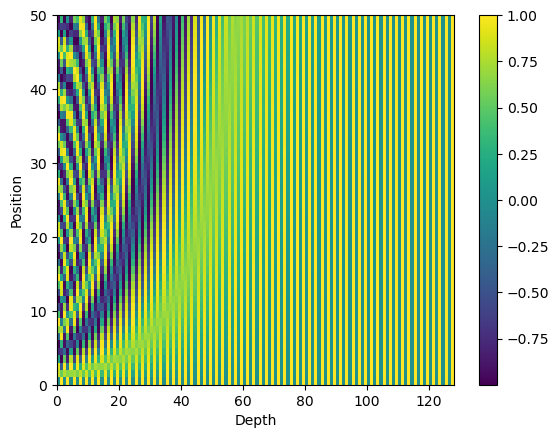

In [12]:
#embedding
class TransformerEmbedding:
    def __init__(self, config):
        super().__init__()
        self.vocab_size = config["vocab_size"]
        self.hidden_size = config["d_model"]
        self.pad_idx = config["pad_idx"]
        dropout_rate = config["dropout"]
        self.max_length = config["max_length"]
        
        self.word_embedding = nn.Embedding(
            self.vocab_size, self.hidden_size, padding_idx=self.pad_idx
        )
        self.pos_embedding = nn.Embedding(
            self.max_length,
            self.hidden_size,
            _weight=self.get_positional_encoding(
                self.max_length, self.hidden_size
            ),
        )
        self.pos_embedding.weight.requires_grad_(False)
        self.dropout = nn.Dropout(dropout_rate)
        
    def get_word_embedding_weights(self):
        return self.word_embedding.weight

    @classmethod
    def get_positional_encoding(self, max_length, hidden_size):
        pe = torch.zeros(max_length, hidden_size)
        position = torch.arange(0, max_length).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, hidden_size, 2)
            * -(torch.log(torch.Tensor([10000.0])) / hidden_size)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, input_ids):
        seq_len = input_ids.shape[1]
        assert (
            seq_len <= self.max_length
        ), f"input sequence length should no more than {self.max_length} but got {seq_len}"

        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        word_embeds = self.word_embedding(input_ids)
        pos_embeds = self.pos_embedding(position_ids)
        embeds = word_embeds + pos_embeds
        embeds = self.dropout(embeds)

        return embeds


def plot_position_embedding(position_embedding):
    plt.pcolormesh(position_embedding)
    plt.xlabel('Depth')
    plt.ylabel('Position')
    plt.colorbar()
    plt.show()

position_embedding = TransformerEmbedding.get_positional_encoding(50, 128)
plot_position_embedding(position_embedding)

In [13]:
config ={
    "vocab_size": 100,
    "d_model": 512,
    "pad_idx": 0,
    "max_length": 64,
    "dropout": 0.1,
}
input_ids = torch.randint(0,100,(2,50))
embeds = TransformerEmbedding(config)(input_ids)
embeds.shape

TypeError: 'TransformerEmbedding' object is not callable

In [ ]:
from dataclasses import dataclassl
from typing import List, Optional

Tensor = torch.Tensor

@dataclass
class AttentionOutput:
    hidden_states: Tensor
    attn_scores: Tensor

class MultiHeadAttentionOutput(AttentionOutput):
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config["d_model"]
        self.num_heads = config["num_heads"]
        assert (
            self.hidden_size % self.num_heads == 0
        ), "Hidden size must be divisible by num_heads but got {} and {}".format(
            self.hidden_size, self.num_heads
        )
        self.head_dim = self.hidden_size // self.num_heads

        self.Wq = nn.Linear(self.hidden_size, self.hidden_size, bias=False) #第二个self.hidden_size可以*系数
        self.Wk = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.Wv = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.Wo = nn.Linear(self.hidden_size, self.hidden_size, bias=False) # 输出层

    def _split_heads(self, x: Tensor) -> Tensor:
        bs, seq_len, _ = x.shape
        x = x.view(bs, seq_len, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)

    def _merge_heads(self, x: Tensor) -> Tensor:
        bs, _, seq_len, _ = x.shape
        return x.permute(0, 2, 1, 3).reshape(bs, seq_len, self.hidden_size)

    def forward(self, querys, keys, values, attn_mask=None) -> AttentionOutput:
        querys = self._split_heads(self.Wq(querys))
        values = self._split_heads(self.Wv(values))

        qk_logits = torch.matmul(querys, keys.mT)
        if attn_mask is not None:
            attn_mask = attn_mask[:, :, : querys.shape[-2], : keys.shape[-2]]
            qk_logits += attn_mask * -1e9
        attn_scores = F.softmax(qk_logits / (self.head_dim**0.5), dim=-1)

        embeds = torch.matmul(attn_scores, values)
        embeds = self.Wo(self._merge_heads(embeds))

        return AttentionOutput(hidden_states=embeds, attn_scores=attn_scores)

mha = MultiHeadAttention({"num_heads": 2, "d_model": 2})
query = torch.randn(2, 3, 2)
query /= query.norm(dim=-1, keepdim=True)
key_value = torch.randn(2, 4, 2)
print(f'key_value.shape {key_value.shape}')
outputs = mha(query, key_value, key_value)
print(outputs.hidden_states.shape)
print(outputs.attn_scores.shape)

In [ ]:
import torch.nn.functional as F

x = torch.randn(2, 3)
x_softmax = F.softmax(x, dim=-1)
print(x_softmax)

outputs.attn_scores.shape[:2]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axis = plt.subplots(*outputs.attn_scores.shape[:2])
for i in range(outputs.attn_scores.shape[0]):
    for j in range(outputs.attn_scores.shape[1]):
        axis[i, j].matshow(outputs.attn_scores[i, j].detach().numpy())
        for x in range(outputs.attn_scores.shape[2]):
            for y in range(outputs.attn_scores.shape[3]):
                axis[i, j].text(y, x, f"{outputs.attn_scores[i, j, x, y]:.2f}", ha="center", va="center", color="w")
fig.suptitle("multi head attention without mask")
plt.show()

In [ ]:
mask_base = torch.Tensor([[0, 0, 1, 1],
                          [0, 0, 1, 1],
                          [0, 0, 1, 1]])
mask = torch.stack([
    mask_base,
    torch.zeros_like(mask_base)
], dim=0).unsqueeze(1)
print(mask.shape)

In [ ]:
outputs_masked = mha(query, key_value, key_value, mask)
fig, axis = plt.subplots(*outputs_masked.attn_scores.shape[:2])
for i in range(query.shape[0]):
    for j in range(outputs_masked.attn_scores.shape[1]):
        axis[i, j].matshow(outputs_masked.attn_scores[i, j].detach().numpy())
        for x in range(outputs_masked.attn_scores.shape[2]):
            for y in range(outputs_masked.attn_scores.shape[3]):
                axis[i, j].text(y, x, f"{outputs_masked.attn_scores[i, j, x, y]:.2f}", ha="center", va="center", color="w")
fig.suptitle("multi head attention with mask")
plt.show()

In [ ]:
#Transformer-Block
from dataclasses import dataclass


@dataclass
class TransformerBlockOutput:
    hidden_states: Tensor
    self_attn_scores: Tensor
    cross_attn_scores: Optional[Tensor] = None
    

class TransformerBlock(nn.Module):
    def __init__(self, config, add_cross_attention=False):
        super().__init__()
        self.hidden_size = config["d_model"]
        self.num_heads = config["num_heads"]
        dropout_rate = config["dropout"]
        ffn_dim = config["dim_feedforward"]
        eps = config["layer_norm_eps"]
        
        self.self_atten = MultiHeadAttention(config)
        self.self_ln = nn.LayerNorm(self.hidden_size, eps=eps)
        self.self_dropout = nn.Dropout(dropout_rate)
        
        if add_cross_attention:
            self.cross_atten = MultiHeadAttention(config)
            self.cross_ln = nn.LayerNorm(self.hidden_size, eps=eps)
            self.cross_dropout = nn.Dropout(dropout_rate)
        else:
            self.cross_atten = None
        
        self.ffn = nn.Sequential(
            nn.Linear(self.hidden_size, ffn_dim),
            nn.ReLU(),
            nn.Linear(ffn_dim, self.hidden_size),
        )
        self.ffn_ln = nn.LayerNorm(self.hidden_size, eps=eps)
        self.ffn_dropout = nn.Dropout(dropout_rate)
        
    def forward(
        self,
        hidden_states,
        attn_mask=None,
        encoder_outputs=None,
        cross_attn_mask=None,
    ):

        self_atten_output = self.self_atten(
            hidden_states, hidden_states, hidden_states, attn_mask
        )
        self_embeds = self.self_ln(
            hidden_states + self.self_dropout(self_atten_output.hidden_states)
        ) 
        
        if self.cross_atten is not None:
            assert encoder_outputs is not None
            cross_atten_output = self.cross_atten(
                self_embeds, encoder_outputs, encoder_outputs, cross_attn_mask
            )
            cross_embeds = self.cross_ln(
                self_embeds + self.cross_dropout(cross_atten_output.hidden_states)
            )

        # FFN
        embeds = cross_embeds if self.cross_atten is not None else self_embeds
        ffn_output = self.ffn(embeds)
        embeds = self.ffn_ln(embeds + self.ffn_dropout(ffn_output))

        return TransformerBlockOutput(
            hidden_states=embeds,
            self_attn_scores=self_atten_output.attn_scores,
            cross_attn_scores=cross_atten_output.attn_scores
            if self.cross_atten is not None
            else None,
        )

In [ ]:
#encoder
from typing import List
@dataclass
class TransformerEncoderOutput:
    last_hidden_states: Tensor
    attn_scores: List[Tensor]

class TransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_layers = config["num_encoder_layers"]
        self.layers = nn.ModuleList(
            [TransformerBlock(config) for _ in range(self.num_layers)]
        )
        
    def forward(self, encoder_inputs_embeds, attn_mask=None) -> TransformerEncoderOutput:
        attn_scores = []
        for layer in self.layers:
            block_outputs = layer(embeds, attn_mask=attn_mask)
            embeds = block_outputs.hidden_states
            attn_scores.append(block_outputs.self_attn_scores)

        return TransformerEncoderOutput(
            last_hidden_states=embeds, attn_scores=attn_scores
        )


In [ ]:
test_config = {
    "num_encoder_layers": 2,
    "d_model": 8,
    "num_heads": 2,
    "dim_feedforward": 16,
    "dropout": 0.1,
    "layer_norm_eps": 1e-5,
}

test_input = torch.randn(2, 5, 8)
encoder = TransformerEncoder(test_config)
encoder.eval()

with torch.no_grad():
    encoder_out = encoder(test_input)

print("last_hidden_states shape:", encoder_out.last_hidden_states.shape)
print("attn_scores num layers:", len(encoder_out.attn_scores))
print("attn_scores[0] shape:", encoder_out.attn_scores[0].shape)

In [ ]:
#decoder
@dataclass
class TransformerDecoderOutput:
    last_hidden_states: Tensor
    self_attn_scores: List[Tensor]
    cross_attn_scores: List[Tensor]


class TransformerDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_layers = config["num_decoder_layers"]
        self.layers = nn.ModuleList(
            [
                TransformerBlock(config, add_cross_attention=True)
                for _ in range(self.num_layers)
            ]
        )

    def forward(
        self,
        decoder_inputs_embeds,
        encoder_outputs,
        attn_mask=None,
        cross_attn_mask=None,
    ) -> TransformerDecoderOutput:
        self_attn_scores = []
        cross_attn_scores = []
        embeds = decoder_inputs_embeds
        for layer in self.layers:
            block_outputs = layer(
                embeds,
                attn_mask=attn_mask,
                encoder_outputs=encoder_outputs,
                cross_attn_mask=cross_attn_mask,
            )
            embeds = block_outputs.hidden_states
            self_attn_scores.append(block_outputs.self_attn_scores)
            cross_attn_scores.append(block_outputs.cross_attn_scores)

        return TransformerDecoderOutput(
            last_hidden_states=embeds,
            self_attn_scores=self_attn_scores,
            cross_attn_scores=cross_attn_scores,
        )


In [ ]:
#mask interview
def generate_square_subsequent_mask(sz: int) -> Tensor:
    mask = (torch.triu(torch.ones(sz, sz)) == 0).transpose(-1, -2).bool()
    return mask

mask = generate_square_subsequent_mask(8)
plt.matshow(mask)
plt.colorbar()
plt.xlabel("keys")
plt.ylabel("querys")
plt.title("1 means mask while 0 means unmask")
plt.show()
print(mask)

In [ ]:
#mask perfomance
inputs_words = ["The quick brown fox jumps over the lazy dog .", "What does the fox say ?"]

inputs_ids, input_mask = tokenizer.encode([w.split() for w in inputs_words], return_mask=True)
print(inputs_ids.shape)
print(input_mask.shape)
for i in range(len(inputs_words)):
    decode_text = tokenizer.decode(inputs_ids[i: i+1].tolist(), remove_bos=False, remove_eos=False, remove_pad=False, split=True)[0]
    print(decode_text)
    self_attn_mask  = input_mask[i].reshape(1, -1).repeat_interleave(inputs_ids.shape[-1], dim=0)
    look_ahead_mask = generate_square_subsequent_mask(inputs_ids.shape[-1])

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].matshow(self_attn_mask)
    axs[0].set_title("self_attn_mask")
    axs[0].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_ylabel("querys")
    axs[0].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_xlabel("keys")
    axs[1].matshow(look_ahead_mask)
    axs[1].set_title("look_ahead_mask")
    axs[1].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_ylabel("querys")
    axs[1].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_xlabel("keys")
    plt.show()